# Task 1: Potential problems in linear regression

In this assignment I will summarize the following three issues that arise when fitting linear regression models: 1)non-linearity of the response-predictor relationships, 2)correlation of error terms, and 3) outliers. I will use Claude AI to generate plots showcasing these problems and investigate solutions. 

In [3]:
# Environment set-up 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.ndimage import uniform_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess

## Issue 1: Non-linearity of the response-predictor relationships

When the response and predictor relationship is non-linear, this is visible with a plot of the residuals. These are the vertical distance between the observed data and the value predicted by a regression model. These are expected to have no discernible shape and if a shape is detected, then there is another underlying pattern in the data.  When the residuals appear non-linear, then the model will not be able to predict the relationship of the data. To correct for this non-linearity, an approach is to use non-linear transformations on the predictors. 

**Question**: *If there are more predictors in the model, is it possible that the residuals could have underlying interactions that are difficult to interpret?*
An approach for a linear regression problem with many predictors is to add interaction terms between predictors, however this can lead to multicollinearity and make it difficult to interpret the coefficents. 

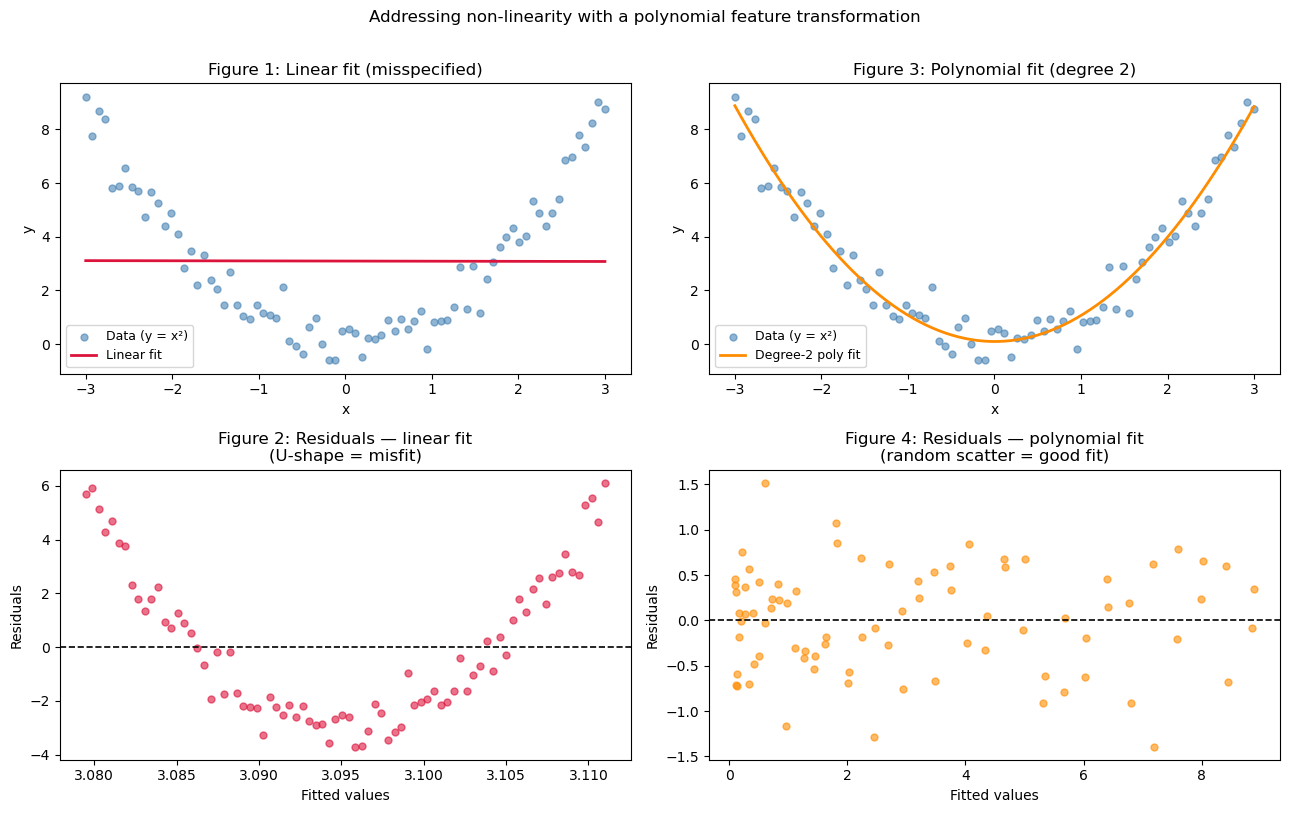

In [5]:

rng = np.random.default_rng(42)
x = np.linspace(-3, 3, 80)
y = x**2 + rng.normal(0, 0.75, size=len(x))

# Linear fit
slope_lin, intercept_lin = np.polyfit(x, y, 1)
fitted_lin = slope_lin * x + intercept_lin
residuals_lin = y - fitted_lin

# Polynomial (degree 2) fit — adds x² feature
coeffs = np.polyfit(x, y, 2)
fitted_poly = np.polyval(coeffs, x)
residuals_poly = y - fitted_poly

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# --- Top left: linear fit ---
ax = axes[0, 0]
ax.scatter(x, y, alpha=0.6, color="steelblue", s=25, label="Data (y = x²)")
ax.plot(x, fitted_lin, color="crimson", linewidth=2, label="Linear fit")
ax.set(xlabel="x", ylabel="y", title="Figure 1: Linear fit (misspecified)")
ax.legend(fontsize=9)

# --- Top right: polynomial fit ---
ax = axes[0, 1]
ax.scatter(x, y, alpha=0.6, color="steelblue", s=25, label="Data (y = x²)")
ax.plot(x, fitted_poly, color="darkorange", linewidth=2, label="Degree-2 poly fit")
ax.set(xlabel="x", ylabel="y", title="Figure 3: Polynomial fit (degree 2)")
ax.legend(fontsize=9)

# --- Bottom left: residuals from linear fit ---
ax = axes[1, 0]
ax.scatter(fitted_lin, residuals_lin, alpha=0.6, color="crimson", s=25)
ax.axhline(0, color="black", linestyle="--", linewidth=1.2)
ax.set(xlabel="Fitted values", ylabel="Residuals", title="Figure 2: Residuals — linear fit\n(U-shape = misfit)")

# --- Bottom right: residuals from polynomial fit ---
ax = axes[1, 1]
ax.scatter(fitted_poly, residuals_poly, alpha=0.6, color="darkorange", s=25)
ax.axhline(0, color="black", linestyle="--", linewidth=1.2)
ax.set(xlabel="Fitted values", ylabel="Residuals", title="Figure 4: Residuals — polynomial fit\n(random scatter = good fit)")

plt.suptitle("Addressing non-linearity with a polynomial feature transformation", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

The plots above show the result of my Claude AI prompt showcasing non-linear synthetic data fit with a linear regression (figure 1). These plots show that there is an underlying relationship between X and Y that is not being modeled with the current linear regression, as seen in Figure 2 plot of the residuals. To adjust for this pattern, fitting the model with a degree 2 polynomial results as seen in Figure 3 results in residuals that appear like a cloud or random scatter, showing that the model fits. 

## Issue 2: Correlation of Error Terms 

Linear regression assumes that the error terms are uncorrelated. If there is a correlation, then the *estimated* standard errors will underestimate the actual standard error. As a result, you can assume your confidence intervals are narrower than they should be. This occurs when data is temporally autocorrelated such as time series data. To know when your data is correlated in this manncan include lagged variables, sample farther apart in time. 

**Question**: *How do you address autocorrelation for clustered data?**
To adjust for this problem within a machine learning context, you can try to preserve the strucutre of the clustered data as much as possible. For the case of the family's height data, you would group by family and height to represent that relationship. 


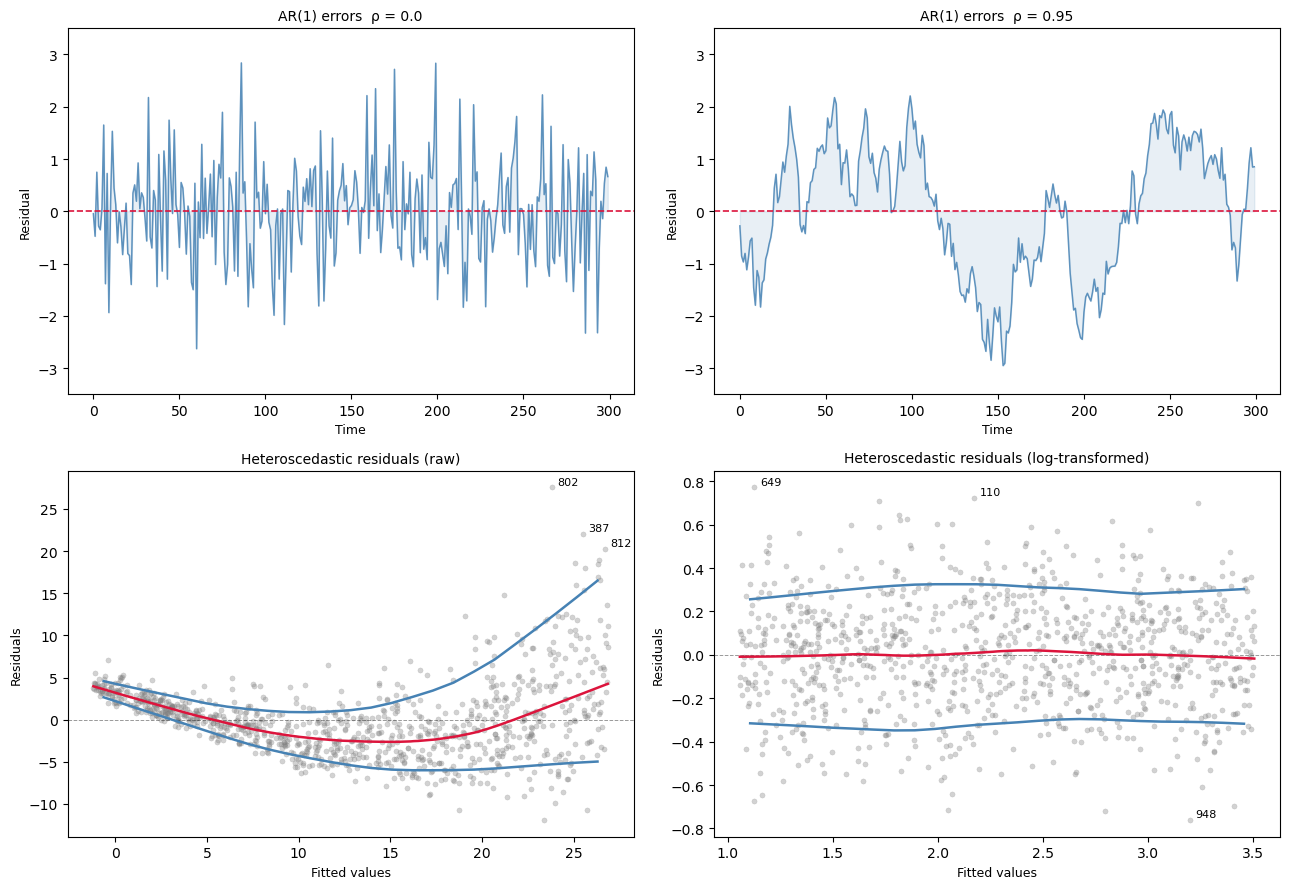

In [4]:

rng = np.random.default_rng(42)
n_ar = 300
x_ar = np.linspace(0, 10, n_ar)
t = np.arange(n_ar)

# --- AR(1) panels ---
def ar1_residuals(rho, x, rng):
    eps = np.zeros(len(x))
    z = rng.normal(size=len(x))
    for i in range(1, len(x)):
        eps[i] = rho * eps[i-1] + np.sqrt(1 - rho**2) * z[i]
    y = 2 + 0.5 * x + eps
    slope, intercept = np.polyfit(x, y, 1)
    return y - (slope * x + intercept)

# --- Heteroscedasticity panels ---
def make_hetero_panel(ax, fitted, resid, title, n_outliers=3):
    ax.scatter(fitted, resid, color="grey", alpha=0.35, s=14,
               linewidths=0.3, edgecolors="grey", zorder=2)

    red = lowess(resid, fitted, frac=0.4, return_sorted=True)
    ax.plot(red[:, 0], red[:, 1], color="crimson", linewidth=1.8, zorder=4)

    bins = 25
    edges = np.linspace(fitted.min(), fitted.max(), bins + 1)
    cx, lo, hi = [], [], []
    for i in range(bins):
        mask = (fitted >= edges[i]) & (fitted < edges[i + 1])
        if mask.sum() > 5:
            cx.append((edges[i] + edges[i + 1]) / 2)
            lo.append(np.quantile(resid[mask], 0.10))
            hi.append(np.quantile(resid[mask], 0.90))
    cx, lo, hi = np.array(cx), np.array(lo), np.array(hi)
    ax.plot(lowess(lo, cx, frac=0.5, return_sorted=True)[:, 0],
            lowess(lo, cx, frac=0.5, return_sorted=True)[:, 1],
            color="steelblue", linewidth=1.8, zorder=3)
    ax.plot(lowess(hi, cx, frac=0.5, return_sorted=True)[:, 0],
            lowess(hi, cx, frac=0.5, return_sorted=True)[:, 1],
            color="steelblue", linewidth=1.8, zorder=3)

    top_idx = np.argsort(np.abs(resid))[-n_outliers:]
    for i in top_idx:
        ax.annotate(str(i), (fitted[i], resid[i]),
                    textcoords="offset points", xytext=(4, 2), fontsize=8)

    ax.axhline(0, color="black", linestyle="--", linewidth=0.7, alpha=0.4)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Fitted values", fontsize=9)
    ax.set_ylabel("Residuals", fontsize=9)

# --- Hetero data ---
n_h = 1000
x_h = rng.uniform(1, 5, n_h)
y_h = np.exp(0.5 + 0.6 * x_h + rng.normal(0, 0.25, n_h))

slope, intercept = np.polyfit(x_h, y_h, 1)
fitted_y  = slope * x_h + intercept
resid_y   = y_h - fitted_y

log_y = np.log(y_h)
slope_l, intercept_l = np.polyfit(x_h, log_y, 1)
fitted_log = slope_l * x_h + intercept_l
resid_log  = log_y - fitted_log

# --- Layout: 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Top row: AR(1)
for col, rho in enumerate([0.0, 0.95]):
    residuals = ar1_residuals(rho, x_ar, rng)
    ax = axes[0, col]
    ax.plot(t, residuals, color="steelblue", linewidth=1.1, alpha=0.85)
    ax.axhline(0, color="crimson", linestyle="--", linewidth=1.2)
    ax.fill_between(t, residuals, 0, alpha=0.12, color="steelblue")
    ax.set_title(f"AR(1) errors  ρ = {rho}", fontsize=10)
    ax.set_ylabel("Residual", fontsize=9)
    ax.set_xlabel("Time", fontsize=9)
    ax.set_ylim(-3.5, 3.5)
# Bottom row: Heteroscedasticity
make_hetero_panel(axes[1, 0], fitted_y,  resid_y,  "Heteroscedastic residuals (raw)")
make_hetero_panel(axes[1, 1], fitted_log, resid_log, "Heteroscedastic residuals (log-transformed)")

plt.tight_layout()
plt.show()

For the plot of residuals with a correlation coefficient of 0, there is no clear correlation and the graph looks like white noise. When correlation is close to ~1, you can see a clear pattern across time in the residuals signifying there is an underlying relationionship between time and the residuals. 

## Issue 3: Outliers
Outliers are values that deviate from the majority of data points in a dataset. They have the ability to change the Residual Standard Error (RSE) and R-squared values. Since RSE feeds directly into confidence intervals and p-values, they can directly influence the conclusions you draw from your model. A way to visualizae outliers is with residual plots. In order to properly detect residuals, you calculate the *studentized residuals*, by dividing each residual by ites estimate standard studentized residual error. If values are greater than |3| then they are considered outliers in the dataset. You can remove outliers/make them NAs however you must be certain it is from human error and not because of a missing predictor in your model. 

**Question**: *How do you adjust if you know your data can have large ranges?*
To adjust your data when you know you have large ranges that can influence model fit, you can use a scalar transformation. 


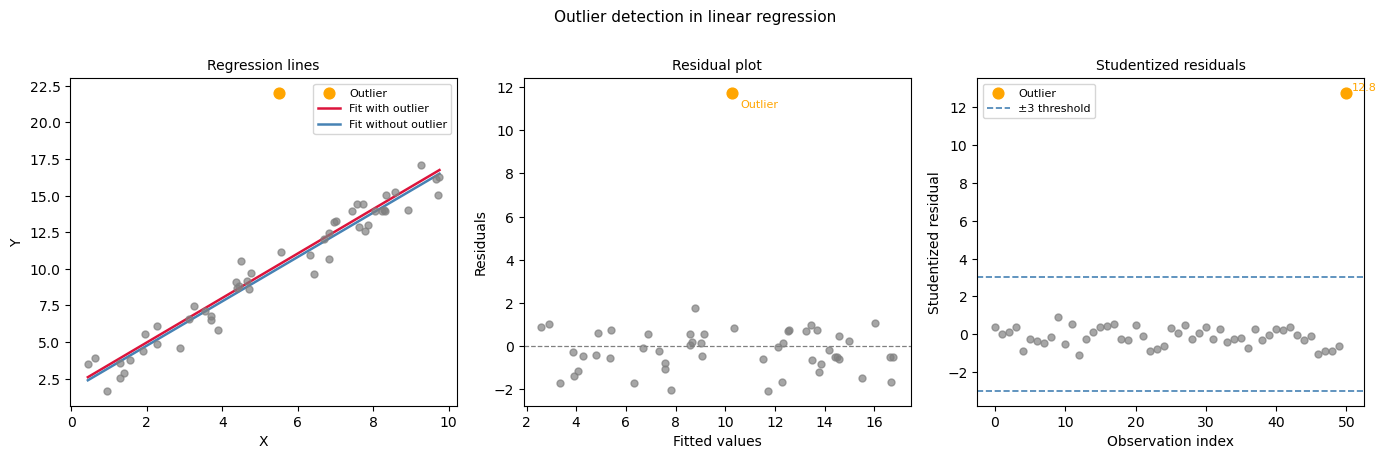

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as t_dist

rng = np.random.default_rng(42)
n = 50
x = rng.uniform(0, 10, n)
y = 2 + 1.5 * x + rng.normal(0, 1.2, n)

# Inject a clear outlier
x = np.append(x, 5.5)
y = np.append(y, 22)
n_total = len(x)

def ols(x, y):
    slope, intercept = np.polyfit(x, y, 1)
    return slope, intercept

# Fit with and without outlier
s, i     = ols(x, y)
s2, i2   = ols(x[:-1], y[:-1])

fitted   = s * x + i
resid    = y - fitted

# Studentized residuals
X = np.column_stack([np.ones(n_total), x])
H = X @ np.linalg.inv(X.T @ X) @ X.T
h = np.diag(H)
mse = np.sum(resid**2) / (n_total - 2)

studentized = np.zeros(n_total)
for j in range(n_total):
    # refit without point j
    mask = np.arange(n_total) != j
    sj, ij = ols(x[mask], y[mask])
    resid_j = y[mask] - (sj * x[mask] + ij)
    mse_j = np.sum(resid_j**2) / (n_total - 3)
    studentized[j] = resid[j] / (np.sqrt(mse_j * (1 - h[j])))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# --- Left: regression lines ---
ax = axes[0]
ax.scatter(x[:-1], y[:-1], color="grey", s=25, alpha=0.7, zorder=3)
ax.scatter(x[-1],  y[-1],  color="orange", s=60, zorder=4, label="Outlier")
xr = np.linspace(x.min(), x.max(), 200)
ax.plot(xr, s  * xr + i,  color="crimson",   linewidth=1.8, label="Fit with outlier")
ax.plot(xr, s2 * xr + i2, color="steelblue", linewidth=1.8, label="Fit without outlier")
ax.set_xlabel("X", fontsize=10)
ax.set_ylabel("Y", fontsize=10)
ax.set_title("Regression lines", fontsize=10)
ax.legend(fontsize=8)

# --- Center: residual plot ---
ax = axes[1]
ax.scatter(fitted[:-1], resid[:-1], color="grey", s=25, alpha=0.7, zorder=3)
ax.scatter(fitted[-1],  resid[-1],  color="orange", s=60, zorder=4, label="Outlier")
ax.axhline(0, color="black", linestyle="--", linewidth=0.9, alpha=0.5)
ax.annotate("Outlier", (fitted[-1], resid[-1]),
            textcoords="offset points", xytext=(6, -10), fontsize=8, color="orange")
ax.set_xlabel("Fitted values", fontsize=10)
ax.set_ylabel("Residuals", fontsize=10)
ax.set_title("Residual plot", fontsize=10)

# --- Right: studentized residuals ---
ax = axes[2]
ax.scatter(range(n_total - 1), studentized[:-1], color="grey", s=25, alpha=0.7, zorder=3)
ax.scatter(n_total - 1,        studentized[-1],  color="orange", s=60, zorder=4, label="Outlier")
ax.axhline( 3, color="steelblue", linestyle="--", linewidth=1.2, label="±3 threshold")
ax.axhline(-3, color="steelblue", linestyle="--", linewidth=1.2)
ax.annotate(f"{studentized[-1]:.1f}", (n_total - 1, studentized[-1]),
            textcoords="offset points", xytext=(4, 2), fontsize=8, color="orange")
ax.set_xlabel("Observation index", fontsize=10)
ax.set_ylabel("Studentized residual", fontsize=10)
ax.set_title("Studentized residuals", fontsize=10)
ax.legend(fontsize=8)

plt.suptitle("Outlier detection in linear regression", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

The plots above show outliers from regression models. The first plot shows regression fitted with the residuals and the second plot shows a plot of residuals with the outlier highlighted. 

## AI Reflection
In this assignment, I prompted Calude AI by asking it to either 1) produce a plot that depicts the issue descried or to 2) recreate the figure caption from the textbook. I found that both prompts proved to work, however I had to ask Claude to remake certain plots to simplify them such as the plot of the correlation of error terms. These originally had different line graphs all with differing AR values, I decided to keep two and add plots of the residuals. Most errors concerned the specification of certain plots, and I mostly went with what the generative AI came up with. 